In [69]:
import numpy as np
import statsmodels.api as sm # recommended import according to the docs
import pickle
import matplotlib.pyplot as plt
import seaborn as sns


PLOTTING_DPI = 500
SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 22

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

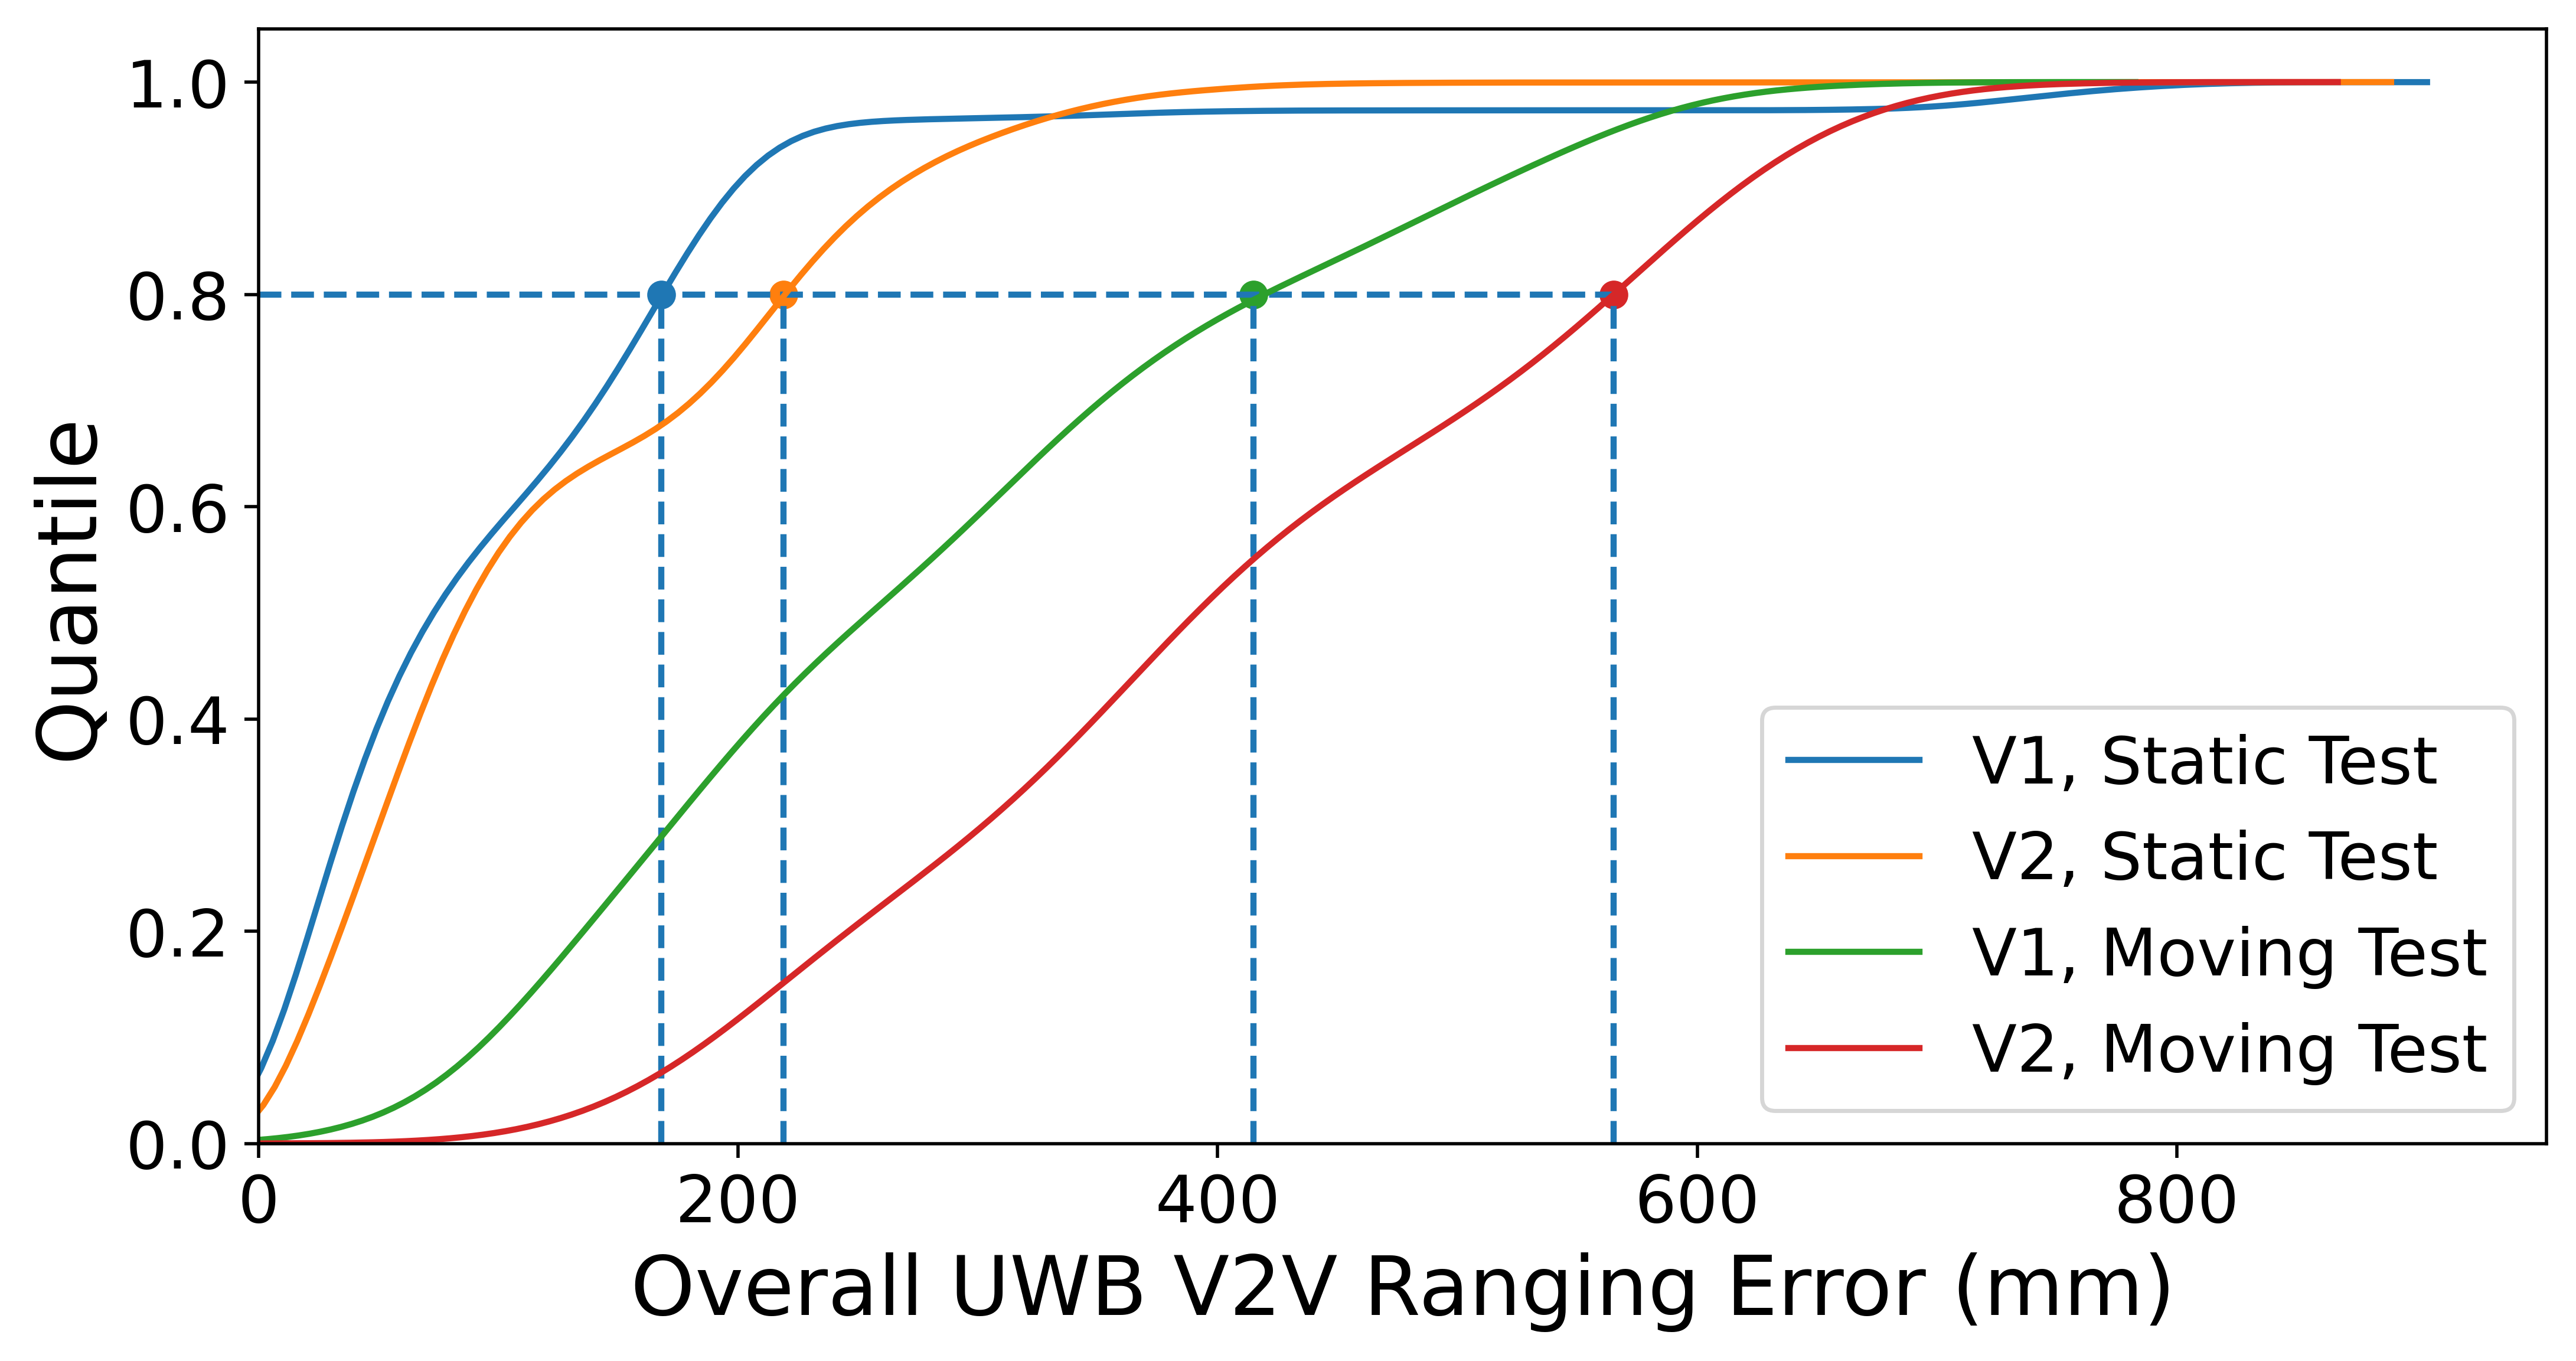

In [72]:
figure = plt.figure(figsize=(10, 5), dpi=PLOTTING_DPI)
ax4 = figure.add_subplot(111)

static_fr = open('static_cdf_results.pickle','rb')
[static_static_sample, static_moving_sample] = pickle.load(static_fr)

moving_fr = open('moving_cdf_results.pickle','rb')
[moving_static_sample, moving_moving_sample] = pickle.load(moving_fr)

sns.kdeplot(ax=ax4,data=static_static_sample,cumulative = True,label='V1, Static Test')
sns.kdeplot(ax=ax4,data=static_moving_sample,cumulative = True,label='V2, Static Test')
sns.kdeplot(ax=ax4,data=moving_static_sample,cumulative = True,label='V1, Moving Test')
sns.kdeplot(ax=ax4,data=moving_moving_sample,cumulative = True,label='V2, Moving Test')

ax4.scatter(static_static_sample.quantile(0.80, interpolation="nearest"), 0.8)
ax4.scatter(static_moving_sample.quantile(0.80, interpolation="nearest"), 0.8)
ax4.scatter(moving_static_sample.quantile(0.80, interpolation="nearest"), 0.8)
ax4.scatter(moving_moving_sample.quantile(0.80, interpolation="nearest"), 0.8)

# plt.vlines(x, 0, y, linestyle="dashed")
plt.hlines(0.8, 0, moving_moving_sample.quantile(0.80, interpolation="nearest"), linestyle="dashed")
plt.vlines(static_static_sample.quantile(0.80, interpolation="nearest"), 0, 0.8, linestyle="dashed")
plt.vlines(static_moving_sample.quantile(0.80, interpolation="nearest"), 0, 0.8, linestyle="dashed")
plt.vlines(moving_static_sample.quantile(0.80, interpolation="nearest"), 0, 0.8, linestyle="dashed")
plt.vlines(moving_moving_sample.quantile(0.80, interpolation="nearest"), 0, 0.8, linestyle="dashed")

lgd = ax4.legend(loc='lower right')

ax4.set_ylabel('Quantile')
ax4.set_xlabel('Overall UWB V2V Ranging Error (mm)')

plt.xlim(0,None)
plt.ylim(0,None)
plt.show()

In [74]:
print(static_static_sample.quantile(0.80, interpolation="nearest"))
print(static_moving_sample.quantile(0.80, interpolation="nearest"))
print(moving_static_sample.quantile(0.80, interpolation="nearest"))
print(moving_moving_sample.quantile(0.80, interpolation="nearest"))

168.0
219.0
414.9709137640748
565.0520601279059
